# Section 1: Notebook Setup & Imports

This section initializes the environment, sets up path resolution, imports libraries for modeling and evaluation, and configures the random seed for reproducibility. We also verify CUDA availability for XGBoost.

In [1]:
import os
import sys
import random
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import torch
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

# Define out_dir globally for 1.1 hyperparameter sweep
out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-hyperparameters-1.1"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Output directory: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.1
Random seed set to 42
XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the Washington-only `derived_8.2` dataset. We concatenate the train and validation sets to form the `trainval` split for model training, parse dates, and extract month and year features.

In [2]:
# Define path configurations
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.2/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.2/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.2/test.csv"

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

Dataset splits loaded:
  train: (15704, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (22853, 500)


# Section 3: Feature & Hyperparameters Configuration

In this section, we load Feature Set V3 (47 features) from `dataset_metadata.py` and programmatically construct the 52 configurations (2 baselines and 50 new hyperparameter/objective sweeps) focused on optimizing around the MSE loss objective.

In [3]:
# Import Feature Sets from dataset_metadata for derived_8.2
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_V3 = dataset_metadata.OVERALL_SELECTED_FEATURES_V3
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set V3 count: {len(FEATURE_SET_V3)}")

MODELS_CONFIG = [
    # 0. Baseline MAE
    {"id": 0, "name": "Baseline (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 9. Baseline MSE
    {"id": 9, "name": "Baseline (MSE)", "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
]

# A: MSE Regularization Grid (18 models, IDs 17-34)
model_id = 17
for depth in [6, 8]:
    for lmb in [0.5, 3.0, 5.0]:
        for alp in [0.0, 0.1, 0.5]:
            MODELS_CONFIG.append({
                "id": model_id,
                "name": f"MSE Reg d={depth} L2={lmb} L1={alp}",
                "objective": "reg:squarederror",
                "max_depth": depth,
                "min_child_weight": 2,
                "reg_lambda": lmb,
                "reg_alpha": alp,
                "subsample": 0.9,
                "colsample_bytree": 0.8
            })
            model_id += 1

# B: MSE Subsampling Grid (12 models, IDs 35-46)
for depth in [6, 8]:
    for sub in [0.7, 0.8, 0.9]:
        for col in [0.6, 0.7]:
            MODELS_CONFIG.append({
                "id": model_id,
                "name": f"MSE Samp d={depth} sub={sub} col={col}",
                "objective": "reg:squarederror",
                "max_depth": depth,
                "min_child_weight": 2,
                "reg_lambda": 1.5,
                "reg_alpha": 0.03,
                "subsample": sub,
                "colsample_bytree": col
            })
            model_id += 1

# C: Huber Loss Slopes (6 models, IDs 47-52)
for slope in [1.5, 2.0, 3.0, 4.0, 6.0, 8.0]:
    MODELS_CONFIG.append({
        "id": model_id,
        "name": f"Huber Slope {slope}",
        "objective": "reg:pseudohubererror",
        "huber_slope": slope,
        "max_depth": 8,
        "min_child_weight": 2,
        "reg_lambda": 1.5,
        "reg_alpha": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.8
    })
    model_id += 1

# D: Learning Rate & Estimators (6 models, IDs 53-58)
MODELS_CONFIG.append({"id": model_id, "name": "MSE Depth 6 LR 0.02", "objective": "reg:squarederror", "max_depth": 6, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.02, "n_estimators": 11000})
model_id += 1
MODELS_CONFIG.append({"id": model_id, "name": "MSE Depth 8 LR 0.02", "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.02, "n_estimators": 11000})
model_id += 1
MODELS_CONFIG.append({"id": model_id, "name": "MSE Depth 6 LR 0.01", "objective": "reg:squarederror", "max_depth": 6, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.01, "n_estimators": 22000})
model_id += 1
MODELS_CONFIG.append({"id": model_id, "name": "MSE Depth 8 LR 0.01", "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.01, "n_estimators": 22000})
model_id += 1
MODELS_CONFIG.append({"id": model_id, "name": "MAE Depth 8 LR 0.02", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.02, "n_estimators": 11000})
model_id += 1
MODELS_CONFIG.append({"id": model_id, "name": "MAE Depth 8 LR 0.01", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.01, "n_estimators": 22000})
model_id += 1

# E: Gamma Grid (8 models, IDs 59-66)
for depth in [6, 8]:
    for gam in [0.01, 0.05, 0.1, 0.2]:
        MODELS_CONFIG.append({
            "id": model_id,
            "name": f"MSE Gamma d={depth} gam={gam}",
            "objective": "reg:squarederror",
            "max_depth": depth,
            "min_child_weight": 2,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "gamma": gam
        })
        model_id += 1

print(f"Total model configurations configured: {len(MODELS_CONFIG)}")

Feature Set V3 count: 47
Total model configurations configured: 52


# Section 4: Training & Timing Loop

In this section, we define the training routine for all 52 model configurations. For each model:
1. We check if the saved model weights (`xgb_model_{id}.json`) and metadata (`xgb_model_{id}_meta.json`) already exist on disk.
2. If they do, we load the model and retrieve the cached training and inference time performance from the metadata.
3. If they do not, we train the model using GPU acceleration (`device="cuda"`), measure the training and inference time performance using `time.perf_counter()`, and save both the model weights and timing metadata back to disk.
4. We generate and cache test set predictions for each configuration to use in final evaluations and plotting.

In [4]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()
X_trainval = trainval_df[FEATURE_SET_V3]
X_test = test_df[FEATURE_SET_V3]

models_dir = out_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Prepare DataFrame to hold predictions
test_predictions_df = test_df[["date", "year", "month", TARGET_COL]].copy()

# Store execution metrics dynamically
trained_models = {}

print("Starting training loop for 52 configurations...\n")
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    
    model_path = models_dir / f"xgb_model_{model_id}.json"
    meta_path = models_dir / f"xgb_model_{model_id}_meta.json"
    
    # Configure parameters dynamically
    params = {
        "objective": config["objective"],
        "random_state": SEED,
        "n_jobs": -1,
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "max_depth": config["max_depth"],
        "min_child_weight": config["min_child_weight"],
        "n_estimators": config.get("n_estimators", 5500),
        "learning_rate": config.get("learning_rate", 0.04),
        "reg_lambda": config["reg_lambda"],
        "reg_alpha": config["reg_alpha"],
        "device": XGB_DEVICE,
    }
    if "huber_slope" in config:
        params["huber_slope"] = config["huber_slope"]
    if "gamma" in config:
        params["gamma"] = config["gamma"]
        
    model = XGBRegressor()
    
    if model_path.exists() and meta_path.exists():
        print(f"[{model_id}] Loading {model_name} from disk...")
        model.load_model(str(model_path))
        with open(meta_path, "r") as f:
            meta = json.load(f)
        train_time = meta["train_time_s"]
        inference_time = meta["inference_time_s"]
        
        # Still predict to populate predictions dataframe
        preds = np.asarray(model.predict(X_test)).ravel()
    else:
        print(f"[{model_id}] Training {model_name} from scratch...")
        model = XGBRegressor(**params)
        
        # Measure training time
        t0 = time.perf_counter()
        model.fit(X_trainval, y_trainval, verbose=0)
        t1 = time.perf_counter()
        train_time = t1 - t0
        
        # Measure inference time
        t2 = time.perf_counter()
        preds = np.asarray(model.predict(X_test)).ravel()
        t3 = time.perf_counter()
        inference_time = t3 - t2
        
        # Save model and meta to disk
        model.save_model(str(model_path))
        meta = {
            "train_time_s": train_time,
            "inference_time_s": inference_time,
            "params": {k: v for k, v in params.items() if k != "device"}
        }
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)
            
        print(f"  Training time:  {train_time:.2f}s")
        print(f"  Inference time: {inference_time:.4f}s")
        
    test_predictions_df[f"pred_{model_id}"] = preds
    config["train_time_s"] = train_time
    config["inference_time_s"] = inference_time
    trained_models[model_id] = model

print("\nAll 52 models processed.")
# Save predictions DataFrame
test_predictions_df.to_csv(out_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions to: {out_dir / 'test_predictions.csv'}")

Starting training loop for 52 configurations...

[0] Loading Baseline (MAE) from disk...


[9] Loading Baseline (MSE) from disk...


[17] Loading MSE Reg d=6 L2=0.5 L1=0.0 from disk...


[18] Loading MSE Reg d=6 L2=0.5 L1=0.1 from disk...


[19] Loading MSE Reg d=6 L2=0.5 L1=0.5 from disk...


...

[61] Loading MSE Gamma d=6 gam=0.1 from disk...
[62] Loading MSE Gamma d=6 gam=0.2 from disk...


[63] Loading MSE Gamma d=8 gam=0.01 from disk...


[64] Loading MSE Gamma d=8 gam=0.05 from disk...
[65] Loading MSE Gamma d=8 gam=0.1 from disk...


[66] Loading MSE Gamma d=8 gam=0.2 from disk...

All 52 models processed.


Saved test predictions to: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.1\test_predictions.csv


# Section 5: Metric Evaluation & Timing Summary

In this section, we evaluate the overall performance of all 52 model configurations on the held-out test split. We compute key statistical metrics ($R^2$, RMSE, ubRMSE, Bias, MAE, Median Absolute Error, and Pearson correlation) along with the recorded training and inference times. The results are compiled into a unified comparison table and saved to `metrics_summary.csv`.

In [5]:
# Define compute_metrics utility
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

# Compile summary metrics
summary_records = []
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    preds = test_predictions_df[f"pred_{model_id}"]
    
    metrics = compute_metrics(y_test, preds)
    metrics["Configuration"] = model_name
    metrics["Train Time (s)"] = config["train_time_s"]
    metrics["Inference Time (s)"] = config["inference_time_s"]
    summary_records.append(metrics)

summary_df = pd.DataFrame(summary_records)
# Reorder columns
cols_order = ["Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson", "Train Time (s)", "Inference Time (s)"]
summary_df = summary_df[cols_order]

summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)
print("===== COMPARATIVE PERFORMANCE & TIMING SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format,
    'Train Time (s)': '{:,.2f}'.format,
    'Inference Time (s)': '{:,.4f}'.format
}))

===== COMPARATIVE PERFORMANCE & TIMING SUMMARY =====
               Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson Train Time (s) Inference Time (s)
              Baseline (MAE) 0.6474 0.0625 0.0589 -0.0211 0.0475   0.0364  0.8322          34.58             0.3310
              Baseline (MSE) 0.6496 0.0623 0.0587 -0.0209 0.0469   0.0355  0.8340          28.60             0.3296
   MSE Reg d=6 L2=0.5 L1=0.0 0.6332 0.0638 0.0600 -0.0216 0.0479   0.0362  0.8277          16.33             0.3129
   MSE Reg d=6 L2=0.5 L1=0.1 0.6274 0.0643 0.0603 -0.0222 0.0482   0.0359  0.8266          17.22             0.3125
   MSE Reg d=6 L2=0.5 L1=0.5 0.6196 0.0649 0.0611 -0.0221 0.0490   0.0376  0.8230          15.40             0.3471
   MSE Reg d=6 L2=3.0 L1=0.0 0.6304 0.0640 0.0600 -0.0223 0.0481   0.0364  0.8276          16.36             0.3460
   MSE Reg d=6 L2=3.0 L1=0.1 0.6326 0.0638 0.0601 -0.0214 0.0481   0.0361  0.8275          17.21             0.3256
   MSE Reg d=6 L2=3

# Section 6: Overall Residual Plots

This section generates a comprehensive grid comparison of residuals across all 52 configurations. Residuals are plotted as a function of the true soil moisture value (True vs. Residual) to diagnose structural underfitting (mean regression) and error distributions. The resulting figure is saved as `residuals_comparison.png`.

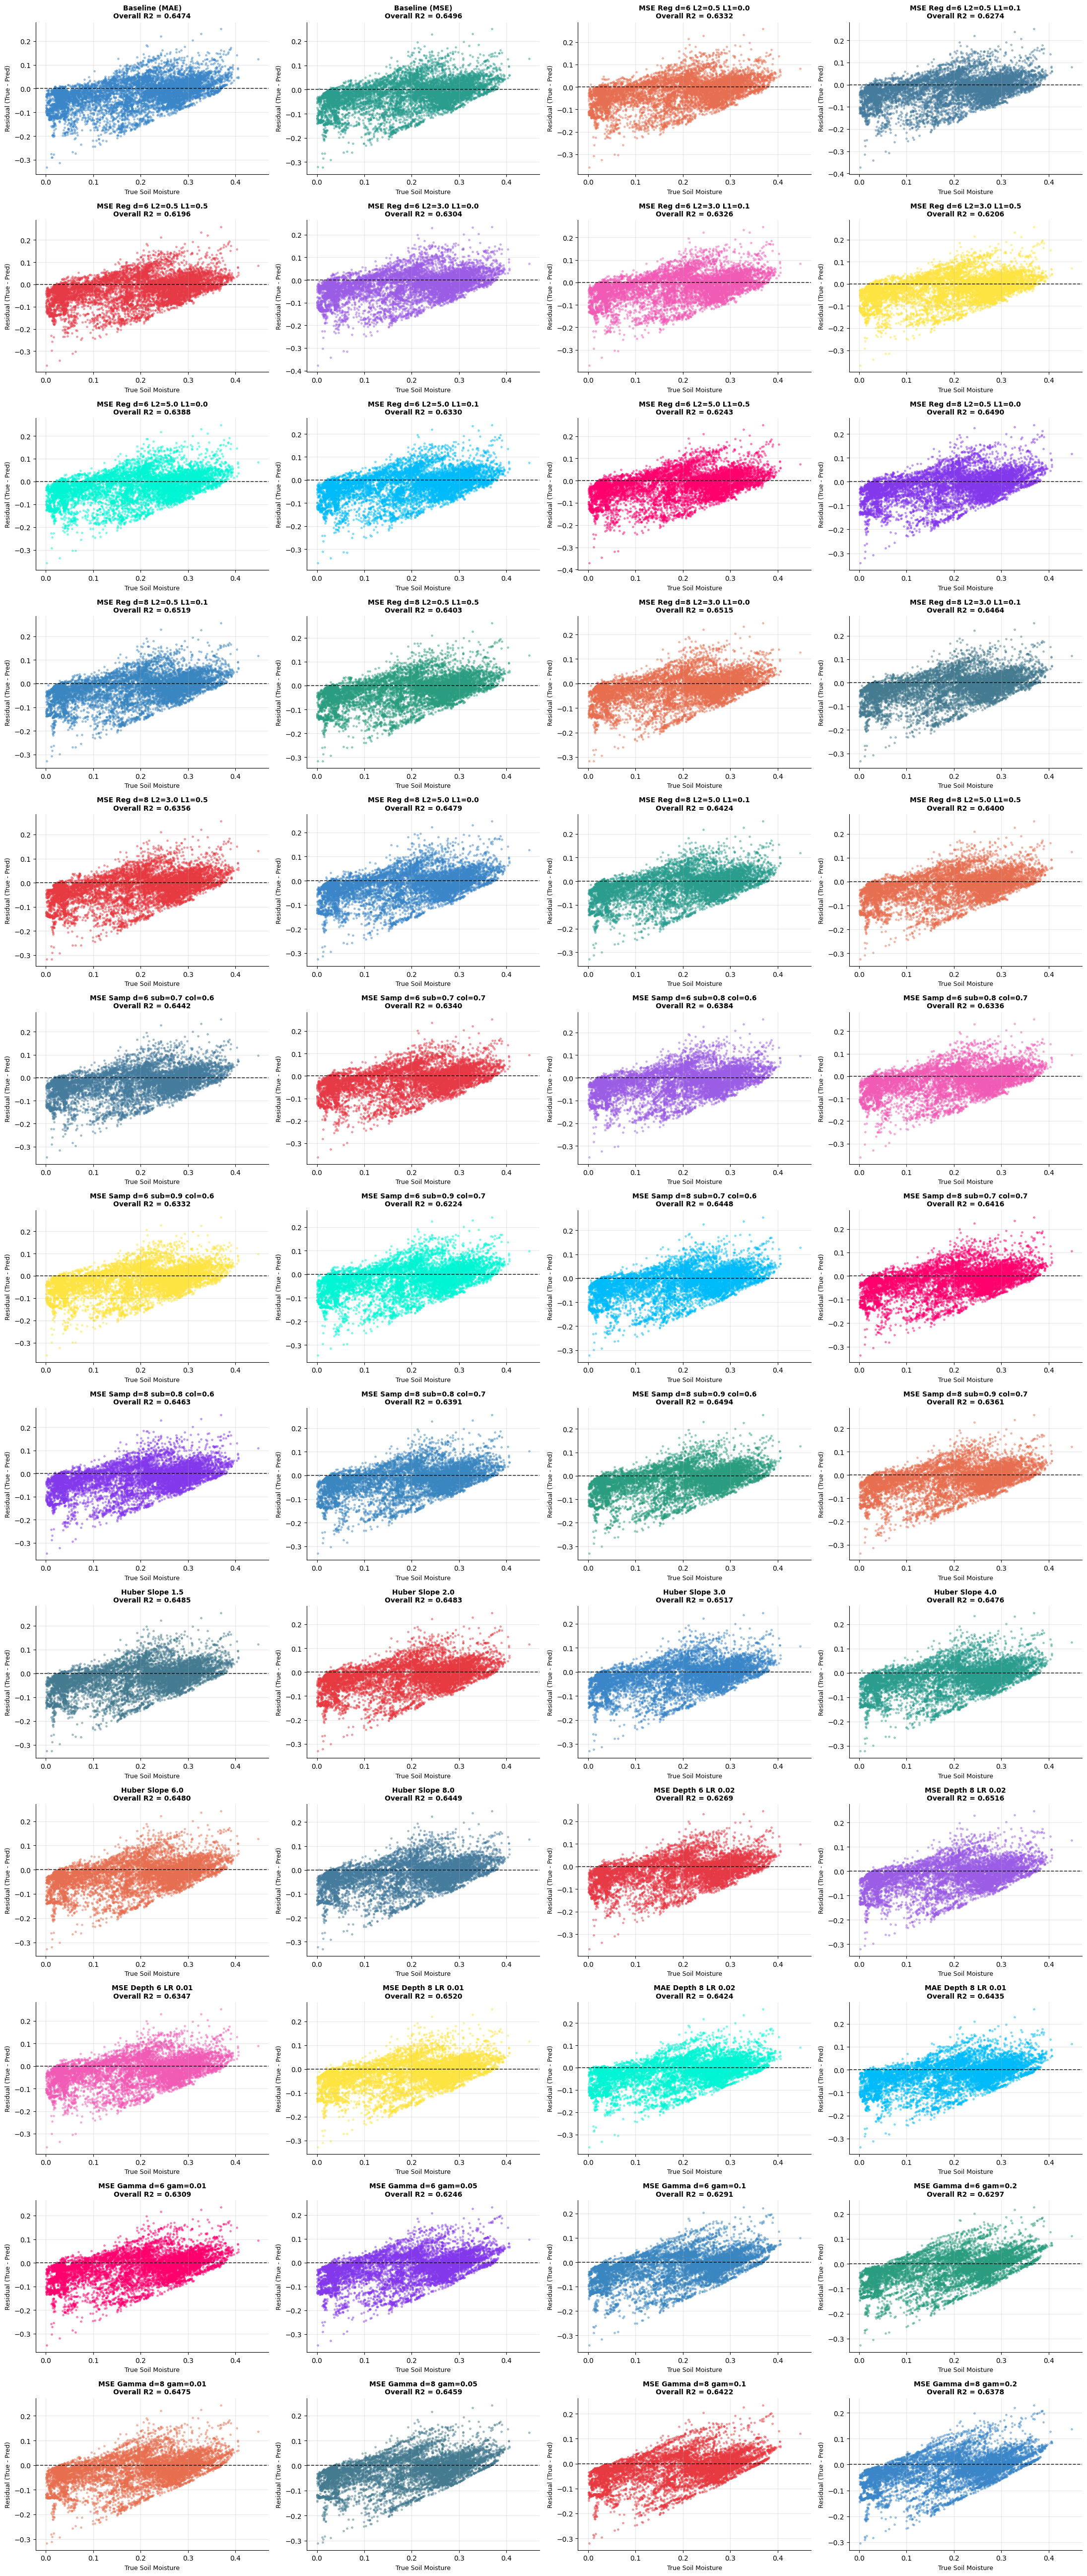

In [6]:
# Plot residuals comparison (13 rows, 4 columns = 52 axes)
fig, axes = plt.subplots(13, 4, figsize=(22, 52))
axes = axes.flatten()

# Curate some distinct colors for the plots
colors_palette = [
    '#3a86c8', '#2a9d8f', '#e76f51', '#457b9d', '#e63946', '#9b5de5', '#f15bb5', '#fee440', '#00f5d4',
    '#00bbf9', '#ff006e', '#8338ec', '#3a86c0', '#2a9d80', '#e76f50', '#457b90', '#e63940'
]

for i, config in enumerate(MODELS_CONFIG):
    model_id = config["id"]
    model_name = config["name"]
    preds = test_predictions_df[f"pred_{model_id}"]
    res = y_test - preds
    r2_val = r2_score(y_test, preds)
    
    ax = axes[i]
    ax.scatter(y_test, res, s=6, alpha=0.4, color=colors_palette[i % len(colors_palette)])
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_xlabel("True Soil Moisture", fontsize=9)
    ax.set_ylabel("Residual (True - Pred)", fontsize=9)
    ax.set_title(f"{model_name}\nOverall R2 = {r2_val:.4f}", fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide any remaining unused subplots (if any)
for j in range(len(MODELS_CONFIG), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png", dpi=150)
plt.show()

# Section 7: Year-by-Year Performance Evaluation & Residuals

In this section, we evaluate each of the 52 configurations separately on each test year (2023, 2024, and 2025) to understand their temporal generalization consistency. We calculate yearly performance metrics and compile them into `metrics_by_year.csv`. To keep the visualization manageable and save memory, we select a representative subset of 7 configurations (representing the baselines and each configuration group) to plot the residuals by year in a 7x3 grid saved as `residuals_by_year.png`.

Test years identified: [np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]



===== YEAR 2023 BASELINES & SAMPLE PERFORMANCES =====
 Year       Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
 2023      Baseline (MAE) 0.6292 0.0655 0.0569 -0.0325 0.0509   0.0406  0.8503
 2023      Baseline (MSE) 0.6423 0.0643 0.0565 -0.0308 0.0503   0.0409  0.8530
 2023     Huber Slope 3.0 0.6488 0.0638 0.0559 -0.0306 0.0497   0.0400  0.8554
 2023 MSE Depth 8 LR 0.01 0.6534 0.0633 0.0556 -0.0303 0.0494   0.0409  0.8577

===== YEAR 2024 BASELINES & SAMPLE PERFORMANCES =====
 Year       Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
 2024      Baseline (MAE) 0.6443 0.0595 0.0571 -0.0169 0.0445   0.0346  0.8308
 2024      Baseline (MSE) 0.6398 0.0599 0.0568 -0.0191 0.0441   0.0338  0.8316
 2024     Huber Slope 3.0 0.6328 0.0605 0.0576 -0.0185 0.0446   0.0342  0.8275
 2024 MSE Depth 8 LR 0.01 0.6380 0.0600 0.0565 -0.0204 0.0443   0.0342  0.8335

===== YEAR 2025 BASELINES & SAMPLE PERFORMANCES =====
 Year       Configuration     R2   RMSE ubRMS

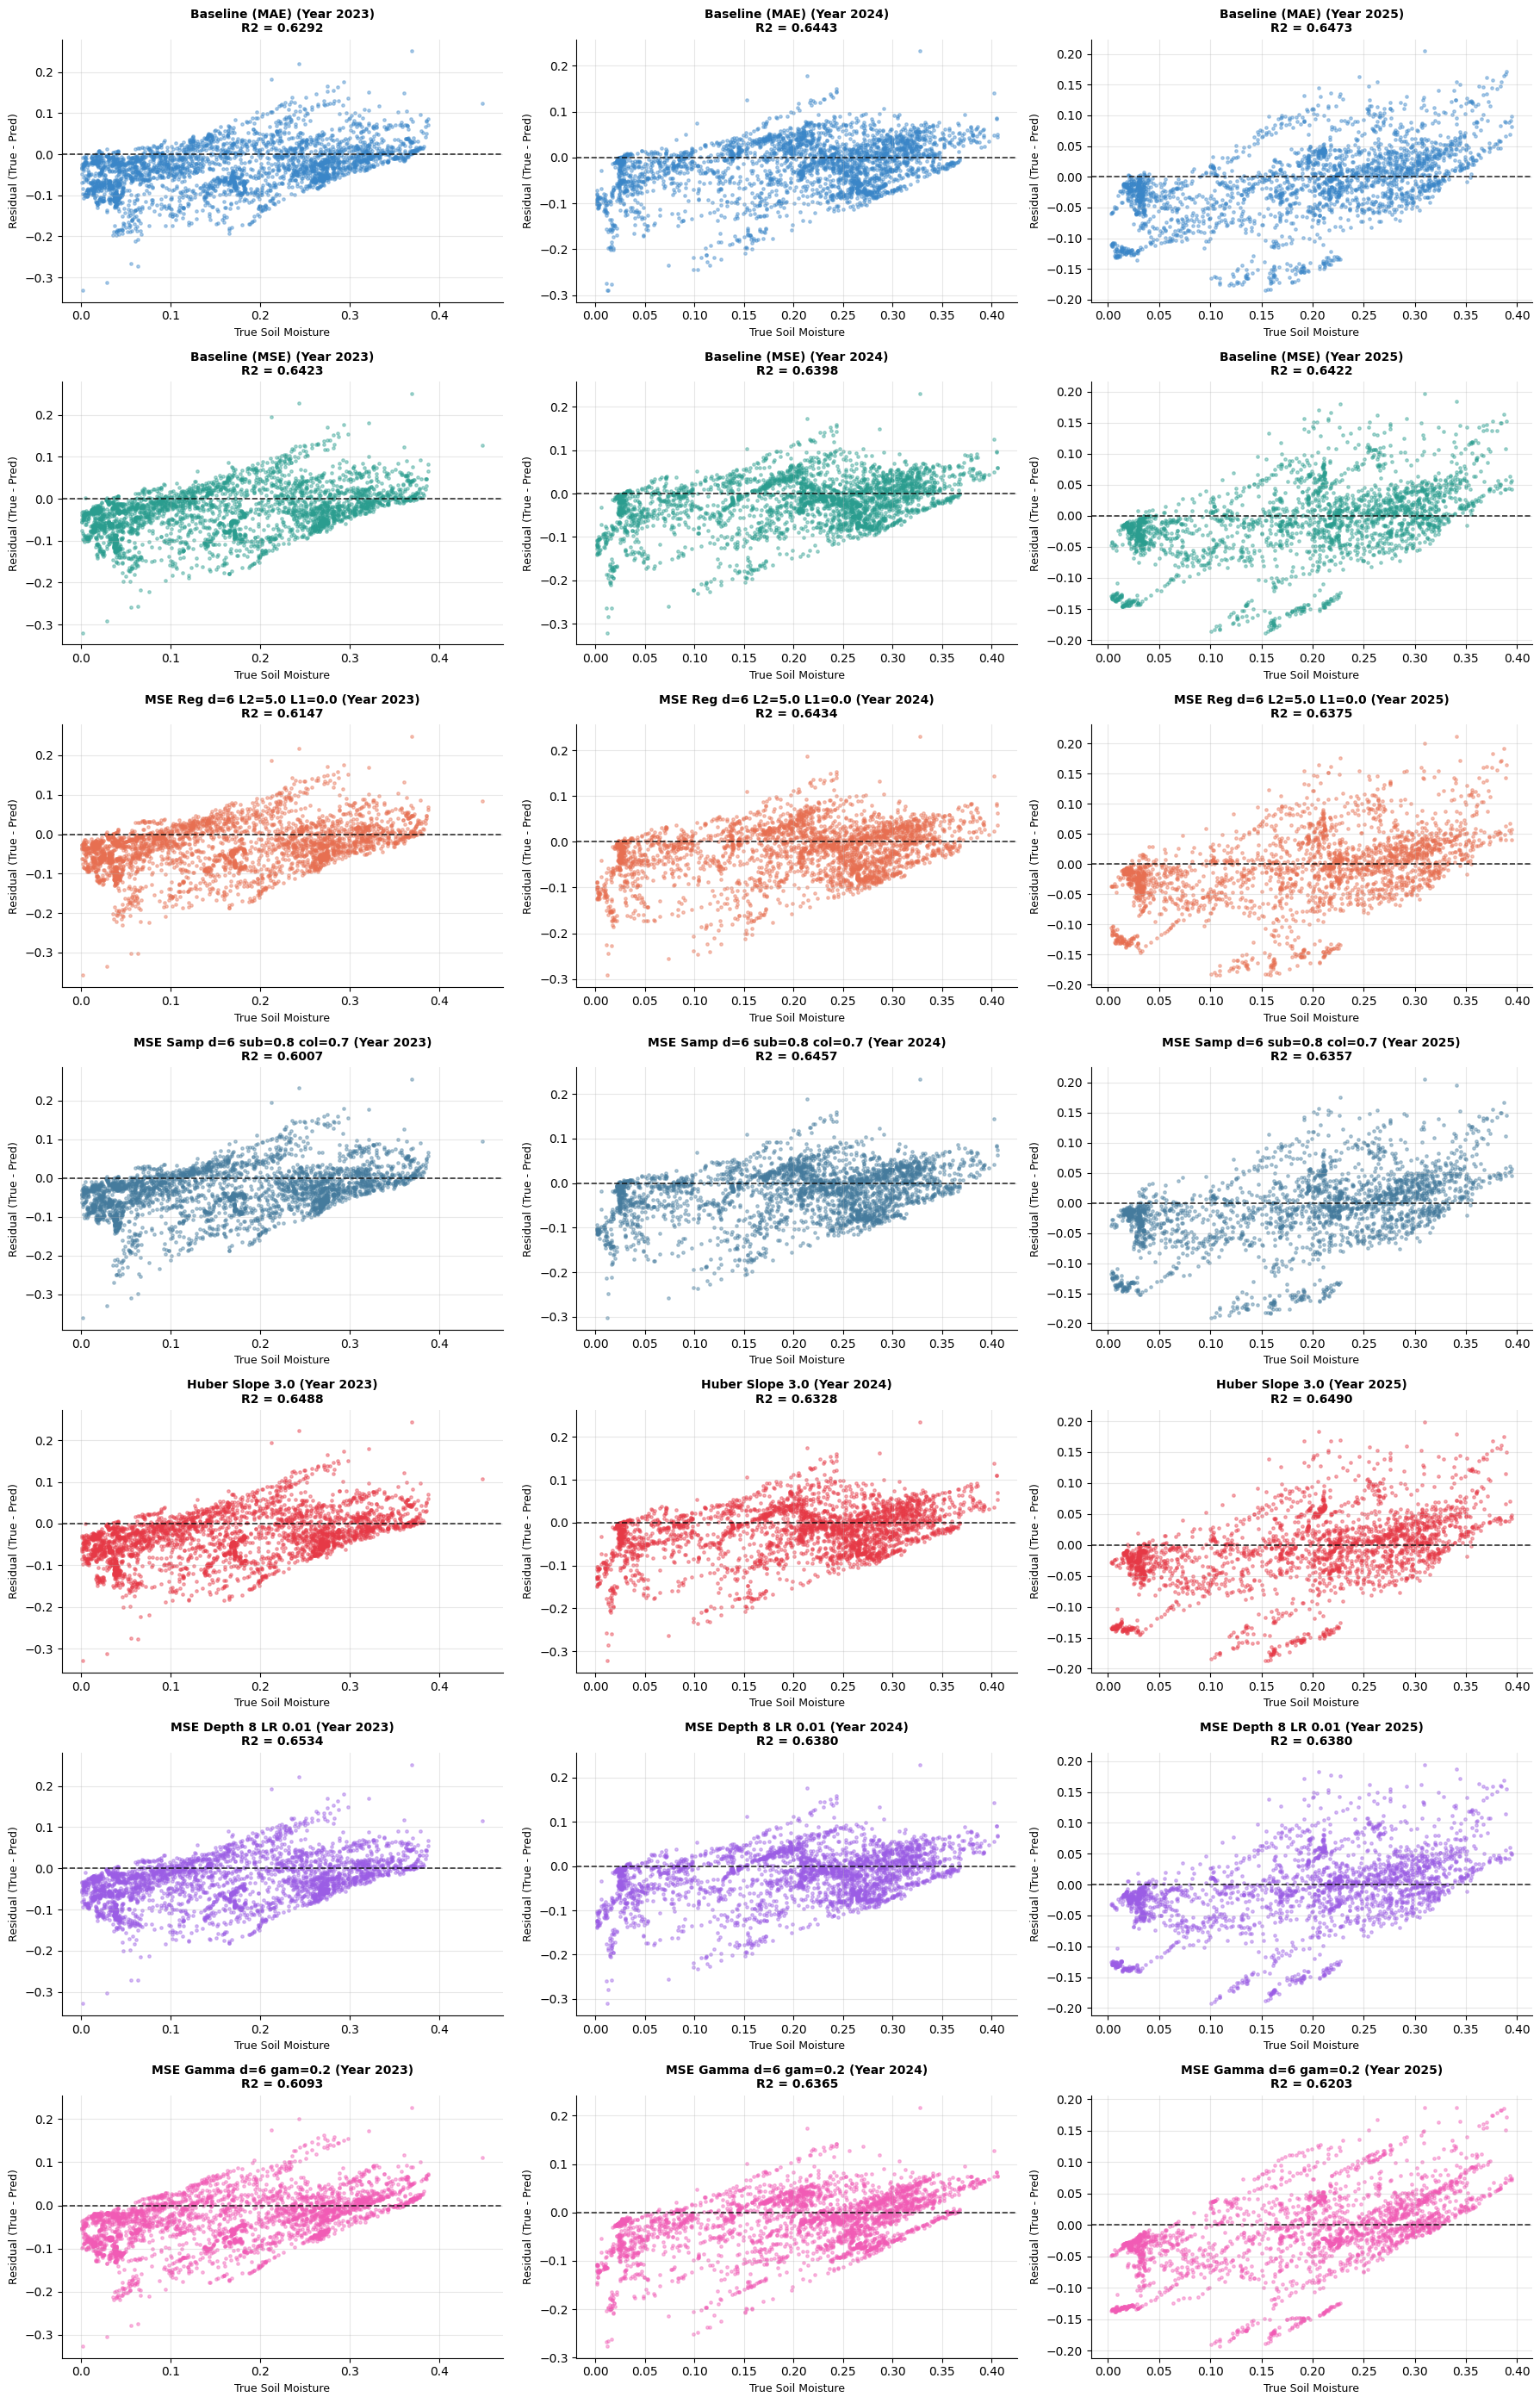

In [7]:
# Identify unique test years
test_years = sorted(test_predictions_df["year"].unique())
print(f"Test years identified: {test_years}")

yearly_records = []

for yr in test_years:
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    for config in MODELS_CONFIG:
        model_id = config["id"]
        model_name = config["name"]
        preds_yr = test_predictions_df[test_predictions_df["year"] == yr][f"pred_{model_id}"].values
        
        metrics_yr = compute_metrics(y_test_yr, preds_yr)
        metrics_yr["Year"] = int(yr)
        metrics_yr["Configuration"] = model_name
        yearly_records.append(metrics_yr)

yearly_summary_df = pd.DataFrame(yearly_records)
# Reorder columns
cols_order_yr = ["Year", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson"]
yearly_summary_df = yearly_summary_df[cols_order_yr]

# Print yearly metrics breakdown for baseline models as a reference
for yr in test_years:
    print(f"\n===== YEAR {int(yr)} BASELINES & SAMPLE PERFORMANCES =====")
    df_yr_m = yearly_summary_df[(yearly_summary_df["Year"] == int(yr)) & (yearly_summary_df["Configuration"].isin([
        "Baseline (MAE)", "Baseline (MSE)", "MSE Depth 8 LR 0.01", "Huber Slope 3.0"
    ]))]
    print(df_yr_m.to_string(index=False, formatters={
        'R2': '{:,.4f}'.format,
        'RMSE': '{:,.4f}'.format,
        'ubRMSE': '{:,.4f}'.format,
        'Bias': '{:+,.4f}'.format,
        'MAE': '{:,.4f}'.format,
        'Med|Err|': '{:,.4f}'.format,
        'Pearson': '{:,.4f}'.format
    }))

yearly_summary_df.to_csv(out_dir / "metrics_by_year.csv", index=False)

# Plot residuals by year for 7 selected representative models (7 rows, 3 columns = 21 axes)
selected_subset = [0, 9, 23, 38, 49, 56, 62] # MAE, MSE, Reg, Samp, Huber, LR, Gamma
fig, axes = plt.subplots(len(selected_subset), 3, figsize=(18, 28))

for r_idx, model_id in enumerate(selected_subset):
    config = next(c for c in MODELS_CONFIG if c["id"] == model_id)
    model_name = config["name"]
    
    for col, yr in enumerate(test_years):
        df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
        y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
        preds_yr = test_predictions_df[test_predictions_df["year"] == yr][f"pred_{model_id}"].values
        res_yr = y_test_yr - preds_yr
        r2_yr = r2_score(y_test_yr, preds_yr)
        
        ax = axes[r_idx, col]
        ax.scatter(y_test_yr, res_yr, s=6, alpha=0.4, color=colors_palette[r_idx % len(colors_palette)])
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
        ax.set_xlabel("True Soil Moisture", fontsize=9)
        ax.set_ylabel("Residual (True - Pred)", fontsize=9)
        ax.set_title(f"{model_name} (Year {int(yr)})\nR2 = {r2_yr:.4f}", fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / "residuals_by_year.png", dpi=150)
plt.show()


# Section 8: Year-by-Year R2 Trend Visualization

To evaluate and compare all 50 new configurations alongside the two baselines, we organize them into 5 distinct plots matching their configuration groups:
1. **Group A**: MSE Regularization Grid (L1/L2 penalties across depths 6 and 8).
2. **Group B**: MSE Subsampling Grid (Instance/feature ratios across depths 6 and 8).
3. **Group C**: Huber Slopes (Pseudo-Huber slopes 1.5 to 8.0 at depth 8).
4. **Group D**: Learning Rate & Estimators (Shrinkage variations down to 0.01).
5. **Group E**: Gamma Grid (Minimum split loss requirements).

The baseline MAE and MSE are plotted on all charts as references. The R2 trends are visualized in a 2x3 layout saved as `r2_by_year.png`.

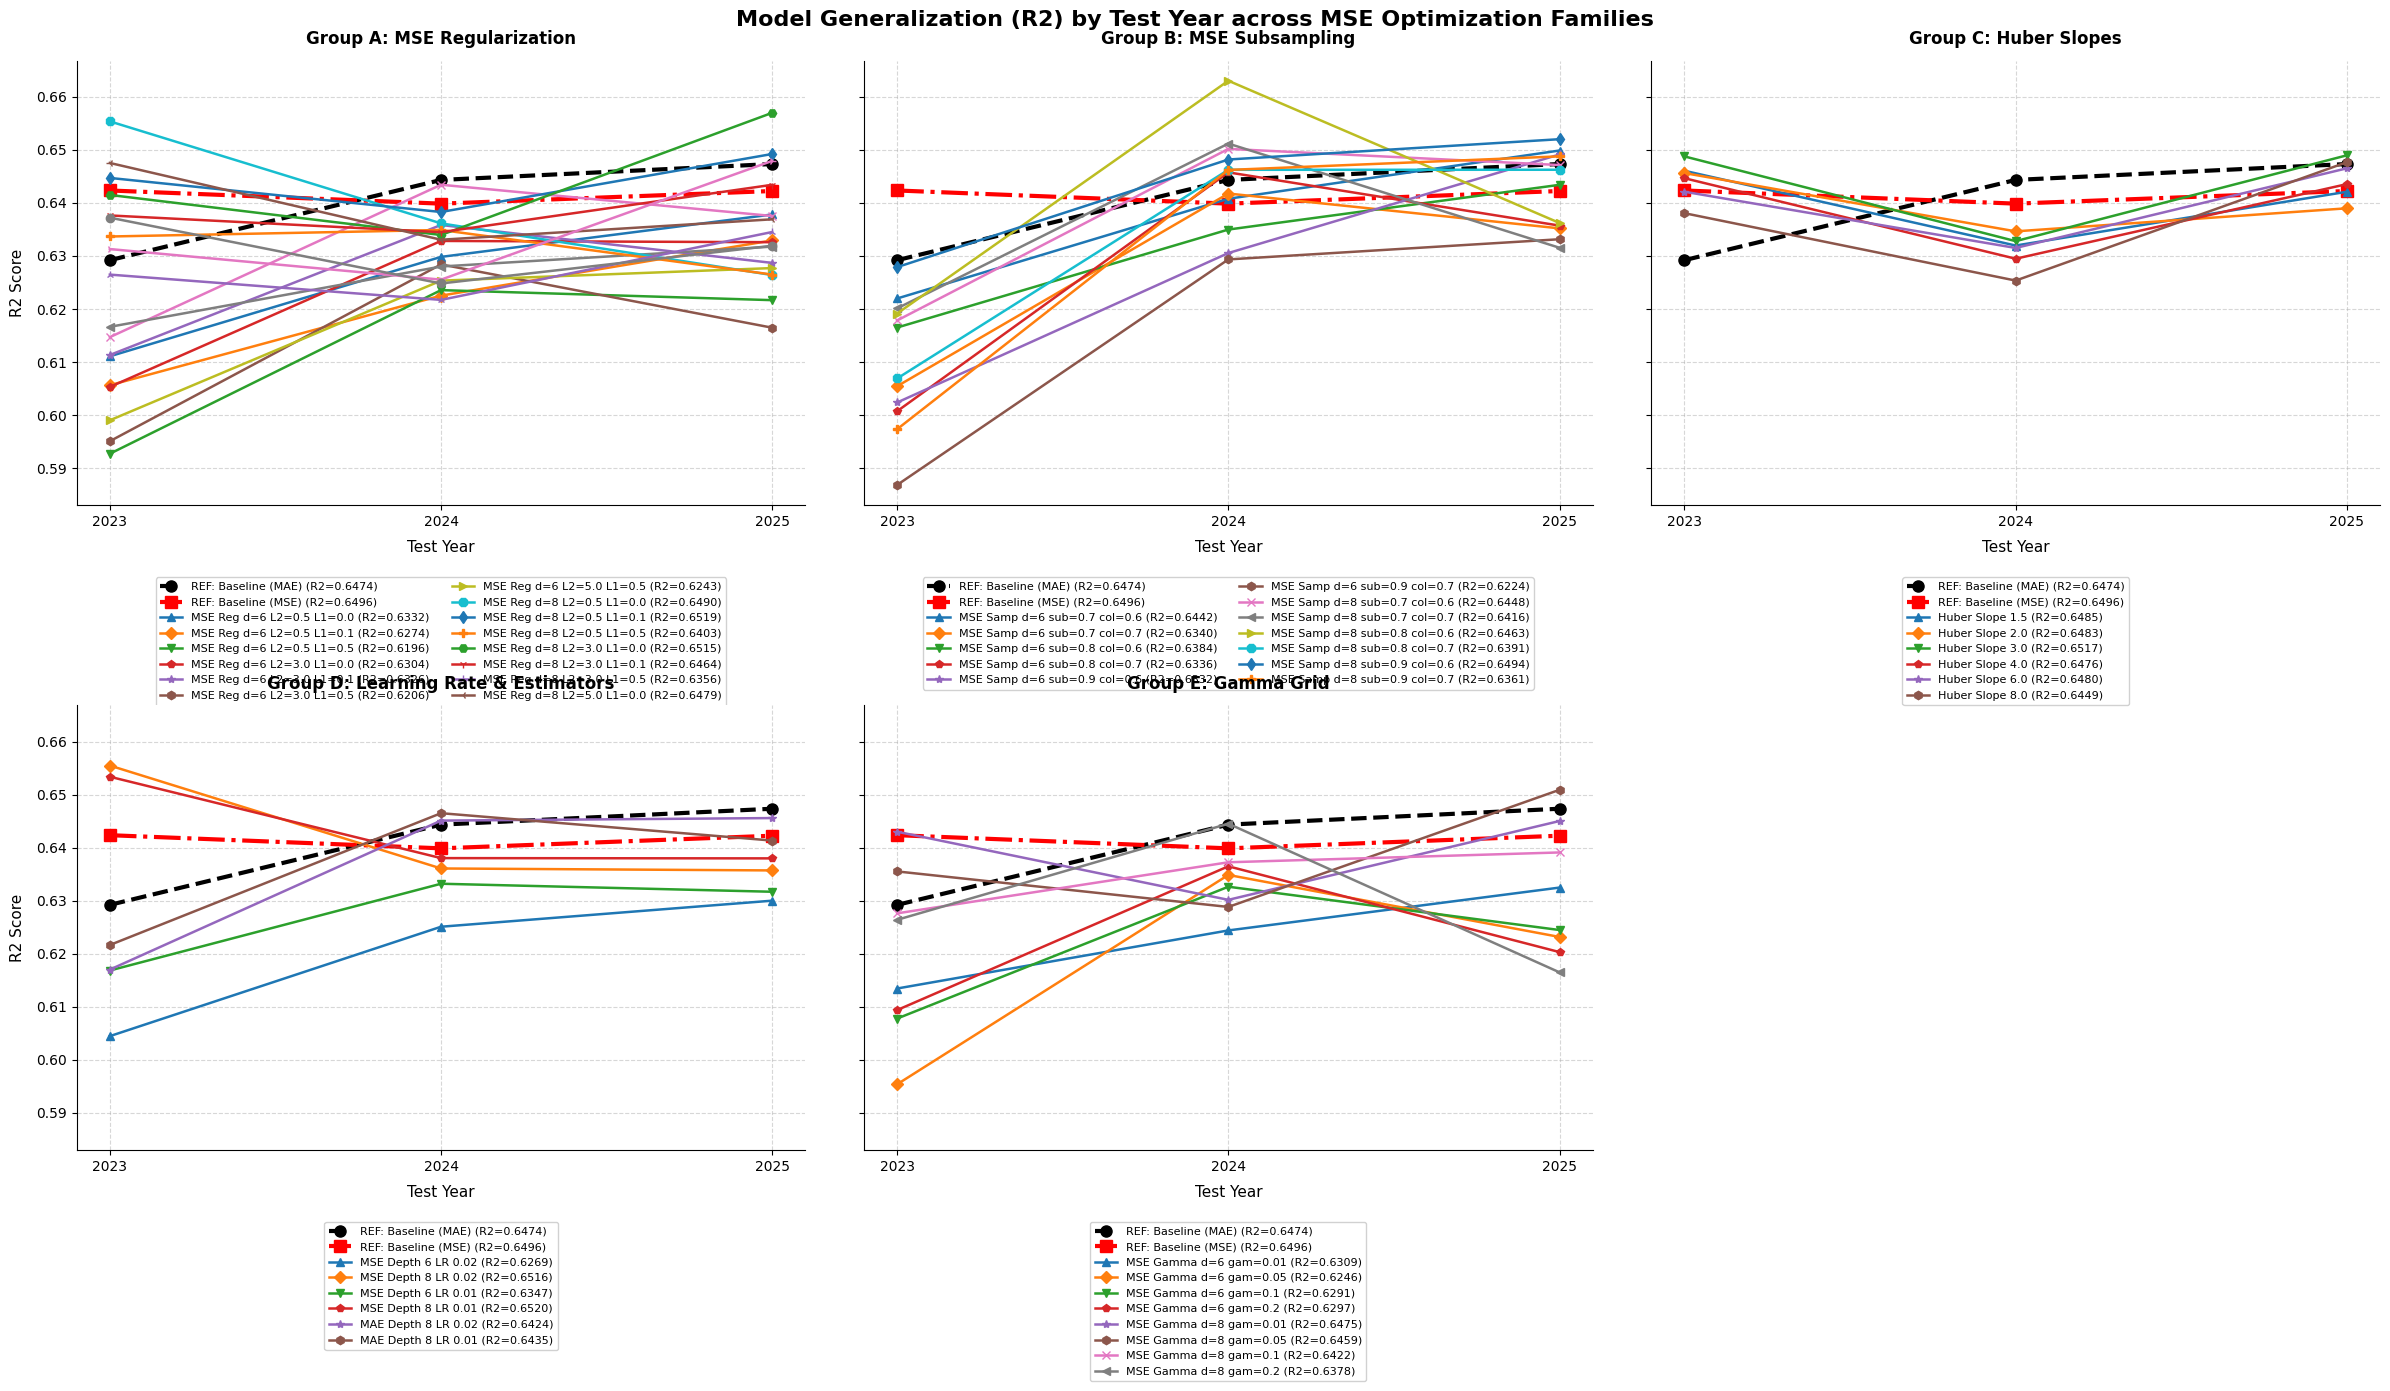

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(24, 15), sharey=True)
axes = axes.flatten()

# Define groupings
group_A_ids = list(range(17, 35))
group_B_ids = list(range(35, 47))
group_C_ids = list(range(47, 53))
group_D_ids = list(range(53, 59))
group_E_ids = list(range(59, 67))

groupings = [
    ("Group A: MSE Regularization", group_A_ids, axes[0]),
    ("Group B: MSE Subsampling", group_B_ids, axes[1]),
    ("Group C: Huber Slopes", group_C_ids, axes[2]),
    ("Group D: Learning Rate & Estimators", group_D_ids, axes[3]),
    ("Group E: Gamma Grid", group_E_ids, axes[4])
]

# Set up unique markers
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'x', '<', '>', '8', 'd', 'P', 'H', '1', '2', '3', '4']

for r_idx, (title, ids, ax) in enumerate(groupings):
    # Always include Model 0 (MAE Baseline) and Model 9 (MSE Baseline) for reference
    reference_ids = [0, 9] + ids
    
    for idx, model_id in enumerate(reference_ids):
        config = next(c for c in MODELS_CONFIG if c["id"] == model_id)
        model_name = config["name"]
        
        # Retrieve yearly performance
        df_model = yearly_summary_df[yearly_summary_df["Configuration"] == model_name].sort_values("Year")
        years = df_model["Year"].values
        r2_vals = df_model["R2"].values
        
        # Retrieve overall R2 for the legend
        overall_r2 = summary_df[summary_df["Configuration"] == model_name]["R2"].values[0]
        
        # Format baseline models differently to stand out
        if model_id == 0:
            ax.plot(years, r2_vals, marker='o', markersize=8, linewidth=3.0, linestyle='--', color='black',
                    label=f"REF: Baseline (MAE) (R2={overall_r2:.4f})")
        elif model_id == 9:
            ax.plot(years, r2_vals, marker='s', markersize=8, linewidth=3.0, linestyle='-.', color='red',
                    label=f"REF: Baseline (MSE) (R2={overall_r2:.4f})")
        else:
            ax.plot(years, r2_vals, marker=markers[idx % len(markers)], markersize=6, linewidth=1.8,
                    label=f"{model_name} (R2={overall_r2:.4f})")
        
    ax.set_xticks(test_years)
    ax.set_xticklabels([str(int(y)) for y in test_years])
    ax.set_xlabel("Test Year", fontsize=11, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Position legends dynamically depending on the group size to avoid clutter
    ncol_leg = 2 if len(ids) > 8 else 1
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=ncol_leg, 
              frameon=True, facecolor='white', framealpha=0.9, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Delete the unused 6th axis
fig.delaxes(axes[5])

axes[0].set_ylabel("R2 Score", fontsize=11, labelpad=8)
axes[3].set_ylabel("R2 Score", fontsize=11, labelpad=8)

plt.suptitle("Model Generalization (R2) by Test Year across MSE Optimization Families", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22, hspace=0.45)
plt.savefig(out_dir / "r2_by_year.png", dpi=300)
plt.show()
